# RB Phase preference panel - Resting state

## Import

In [1]:
import os 
os.chdir('/CSNG/studekat/ripple_paper_clean_copy/code_new_filter')

In [2]:
from functions_analysis import *
import pandas as pd
import numpy as np
import yaml
import pickle
import neo
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import gaussian_filter1d
import matplotlib.gridspec as gridspec
import scipy.stats as stats
from statsmodels.stats.multitest import multipletests
from itertools import combinations
from scipy.stats import kruskal

In [3]:
import warnings
warnings.simplefilter(action='ignore', category=pd.errors.SettingWithCopyWarning)

## Parameters

In [4]:
with open("/CSNG/studekat/ripple_paper_clean_copy/code_new_filter/params_analysis.yml") as f:
    params_analysis = yaml.safe_load(f)

DATA_FOLDER = params_analysis['data_folder'] ### folder with all the preprocessed data
DATES = params_analysis['dates']

DF_FOLDER = '/CSNG/studekat/ripple_paper_clean_copy/dataframes_new_filter' ### here the resulting dataframes will be saved
MONKEY_LIST = ['L','N','F'] 
AREAS_MERGED = params_analysis['areas_merged']
FINAL_CLASSES = params_analysis['final_classes']
CLASS_COLORS = params_analysis['colors_class']
CLASS_NAMES = params_analysis['classes_names']

AREA = 'V12'
SEL_TH = params_analysis['select_th']
DUAL_TH = [2.5,3.5]

In [5]:
### converting two word names of classes into strings on two lines
CLASS_NAMES_PLOTS = []
for name in CLASS_NAMES:
    if len(name.split()) == 2:
        CLASS_NAMES_PLOTS.append(name.replace(" ", "\n"))
    else:
        CLASS_NAMES_PLOTS.append(name)

In [6]:
#CLASS_NAMES_PLOTS = ['Narrow\nBiphasic', 'Medium\nBiphasic', 'Wide', 'Narrow\nTriphasic','Medium\nTriphasic','Positive']
CLASS_NAMES_PLOTS = ['Narr\nBI', 'Med\nBI', 'Wide', 'Narr\nTRI','Med\nTRI','Pos']

In [7]:
CLASS_DICT = {'DOWN_narrow_shallow':'NarrBI',
             'DOWN_narrow_sharp':'NarrTRI',
             'DOWN_wide':'Wide',
             'DOWN_medium_shallow':'MedBI',
             'DOWN_medium_sharp':'MedTRI',
             'UP':'Pos',}

## Data loading

In [8]:
df_merged = load_prop_df(MONKEY_LIST,'RS',params_analysis,DF_FOLDER,exclude_noisy=True)

L
20170725
20170809
20170810
N
20240719_B1
20240719_B2
F
20240122_B1
20241216_B1


In [9]:
# ensure correct threshold is used
df_merged['is_RB_phase_selective'] = df_merged['norm_RB_phase_selectivity_spikes'] > params_analysis['select_th']

In [10]:
df_merged_area = df_merged[df_merged['area_merged']==AREA]

In [11]:
# alignment to the first negative peak - NON-CIRCULAR PHASE DATA
df_first_peak_list = []
for monkey in MONKEY_LIST:
    print(monkey)
    for date in params_analysis['dates'][monkey]['RS']:
        print(date)
        file_name = f'{DF_FOLDER}/ripple_prop_triggered_phase/th__25_35/first_neg_peak_monkey{monkey}_all_arrays_date_{date}.pkl'
        with open(file_name, "rb") as f:
            df_first_neg_peak = pickle.load(f)
        df_first_peak_list.append(df_first_neg_peak)

df_first_neg_peak = pd.concat(df_first_peak_list, ignore_index=True)

L
20170725
20170809
20170810
N
20240719_B1
20240719_B2
F
20240122_B1
20241216_B1


## Saving DF for testing

In [12]:
df_merged_area.keys()

Index(['FR', 'CV_ISI', 'ISI', 'env_th_median', 'list_phases', 'list_env',
       'list_env_phases', 'list_phases_high_env', 'list_env_phases_high_env',
       'list_phases_low_env',
       ...
       'env_th_perc_95_EO', 'amp_wf', 'width_wf', 'avg_wf_zscored',
       'amp_wf_zscored', 'width_wf_class', 'wf_direction', 'final_class',
       'is_RB_phase_selective', 'area_merged'],
      dtype='object', length=111)

In [13]:
select_cols = ['final_class', 'norm_RB_phase_selectivity_spikes','FR_high_env_low_env_median_ratio',
               'norm_RB_phase_selectivity_spikes_EC','FR_high_env_low_env_median_ratio_EC',
               'norm_RB_phase_selectivity_spikes_EO','FR_high_env_low_env_median_ratio_EO']
df_merged_area_minimal = df_merged_area[select_cols]
path = f'{DF_FOLDER}/testing_NATIM_RS'
ensure_dir_exists(path)
df_merged_area_minimal.to_csv(f'{path}/resting_state_props.csv',index=False)

## Functions

In [14]:
# Selectivity boxplots per class, fixed area
def aux_plot_select_boxplot_fig5(df,ax,set_params):
    """
    PANEL 3
    
    Plots comparison of selectivities.
    """
    y_name = set_params['y_select']
    x_name = 'final_class'
    colors_class = set_params['colors_class']
    alpha = set_params['box_alpha']
    font_size = set_params['box_xlabel_fontsize']
    font_rot = set_params['box_xlabel_rotation']
    ax.axhline(set_params['select_th'],color='gray',ls='dashed',linewidth=set_params['box_hline_width'])
    sns.boxplot(data=df,ax=ax,x=x_name,y=y_name,hue=x_name, palette=colors_class, legend=False,
                    linewidth=set_params['box_line_width'],fliersize=False,order=set_params['final_classes'])
    ax.set_xlabel('')
    ax.set_ylabel(set_params['y_label'],fontsize=set_params['box_ylabel_fontsize'])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylim([-0.05,0.7])
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(set_params['class_names'], fontsize=font_size,rotation=font_rot)
    ax.tick_params(axis='both', labelsize=12)
   
    ### setting alpha param.
    for patch in ax.patches:
        r, g, b, _ = patch.get_facecolor()
        patch.set_facecolor((r, g, b, alpha))
    return

In [15]:
# Ratio of selective cells per cell class for a fixed sel. th.
def aux_plot_select_ratios_fig5(df,ax,set_params):
    """
    PANEL 3

    Plots ratio of selective cells in the population.
    """
    select_th = set_params['select_th']
    select_name = set_params['y_select']
    classes = set_params['final_classes']
    colors_class = set_params['colors_class']
    colors_ordered = [colors_class[c] for c in classes]
    alpha = set_params['bars_alpha']
    font_size = set_params['box_xlabel_fontsize']  
    font_rot = set_params['box_xlabel_rotation']
    
    percent_select_dict = {}
    percent_non_select_dict = {}
    num_select_dict = {}
    num_non_select_dict = {}
    for cl in classes:
        df_cl = df[df['final_class']==cl]
        df_sel = df_cl[df_cl[select_name]>=select_th]
        df_non_sel = df_cl[df_cl[select_name]<select_th]
        percent_select_dict[cl] = df_sel.shape[0]/df_cl.shape[0]*100
        percent_non_select_dict[cl] = df_non_sel.shape[0]/df_cl.shape[0]*100
        num_select_dict[cl] = df_sel.shape[0]
        num_non_select_dict[cl] = df_non_sel.shape[0]
        
    width=0.5
    bottom = np.zeros(len(classes))

    bottom_vec = [percent_select_dict[cl] for cl in classes]
    bottom_text = [num_select_dict[cl] for cl in classes]
    ax.bar(range(len(classes)),bottom_vec,color=colors_ordered,bottom=bottom,alpha=alpha)
    bottom+=bottom_vec
    top_vec = [percent_non_select_dict[cl] for cl in classes]
    top_text = [num_non_select_dict[cl] for cl in classes]
    ax.bar(range(len(classes)),top_vec,color='gray',bottom=bottom,alpha=alpha)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    #ax.set_xticks(ax.get_xticks())
    ax.set_xticks(range(len(classes)))
    ax.set_xticklabels(set_params['class_names'], fontsize=font_size,rotation=font_rot)
    ax.set_ylabel('Percentage')

    for i, val in enumerate(top_text):
        ax.text(i, 90, f'{val:.0f}', ha='center', va='bottom', fontsize=9, color='black')

    for i, val in enumerate(bottom_text):
        ax.text(i, 2, f'{val:.0f}', ha='center', va='bottom', fontsize=9, color='black')

    ax.text(5.8,70,'num. non- \n select cells',ha='center',fontsize=9, color='black',rotation=270)
    ax.text(5.8,5,'num. \n select cells',ha='center',fontsize=9, color='black',rotation=270)
    
    return

In [16]:
def plot_CH_panel_fig5(df, set_params,save=False,path=''):
    """
    PANEL 3

    Circular histogram of phase pref. for selective cells.
    """
    # WARNING: in this version, no further filtersing of AREA
    fig, ax = plt.subplots(2,3,subplot_kw={'projection': 'polar'})
    fig.set_figwidth(5)
    fig.set_figheight(4.5)
    
    fig.suptitle(set_params['plot_suptitle'])
    
    axes_indices = [[0,0],[0,1],[0,2],[1,0],[1,1],[1,2]]
    for idx in range(len(set_params['final_classes'])):
        cl = set_params['final_classes'][idx]
        ax_idx = axes_indices[idx]
        df_cl = df[df['final_class']==cl]
        df_sel = df_cl[df_cl[set_params['y_select']]>=set_params['select_th']]
        data = df_sel[set_params['pref_phase']]
    
        bins = np.linspace(-np.pi, np.pi, set_params['n_bins_hist'])
        counts, bin_edges = np.histogram(data, bins=bins)
        angles = (bin_edges[:-1] + bin_edges[1:]) / 2
        widths = np.diff(bin_edges)
        
        bars = ax[ax_idx[0],ax_idx[1]].bar(angles, counts, width=widths, edgecolor='black', align='center',
                                           color=set_params['colors_class'][cl], alpha=0.7)

        if ax_idx[1]==0:
            ax[ax_idx[0],ax_idx[1]].text(3/2*np.pi, max(counts)*1.2, "Before RB Peak", ha='right', va='center', 
                          fontsize=set_params['font_size'],rotation=90)
        if ax_idx[1]==2:
            ax[ax_idx[0],ax_idx[1]].text(1/2*np.pi, max(counts)*1.4, "After RB Peak", ha='right', va='center', 
                          fontsize=set_params['font_size'],rotation=270)
        
        ax[ax_idx[0],ax_idx[1]].set_theta_zero_location("N")  # 0° at the top
        ax[ax_idx[0],ax_idx[1]].set_theta_direction(-1)       # Clockwise direction

        ax[ax_idx[0],ax_idx[1]].set_yticklabels([])
        #ax[ax_idx[0],ax_idx[1]].set_xticks([0, np.pi])
        #ax[ax_idx[0],ax_idx[1]].set_xticklabels(['RB peak \n 0°', '180° \n RB trough'])
        if ax_idx[0]==0:  # TOP ROW
            ax[ax_idx[0],ax_idx[1]].set_xticks([0])
            ax[ax_idx[0],ax_idx[1]].set_xticklabels(['RB Peak \n 0°'],fontsize=set_params['font_size'])
        else:  # BOTTOM ROW
            ax[ax_idx[0],ax_idx[1]].set_xticks([np.pi])
            ax[ax_idx[0],ax_idx[1]].set_xticklabels(['180° \n RB Trough'],fontsize=set_params['font_size'])

    plt.tight_layout()
    plt.show()
    plt.close()
    return

In [17]:
def aux_plot_FR_ratio_boxplot(df,ax,set_params):
    """
    PANEL 3
    
    Plots comparison of FR ratios of High/Low RB for cell classes. (divided by median env.)
    """
    y_name = set_params['FR_ratio_name']
    x_name = 'final_class'
    colors_class = set_params['colors_class']
    alpha = set_params['box_alpha']
    font_size = set_params['box_xlabel_fontsize']
    font_rot = set_params['box_xlabel_rotation']
    ax.axhline(1,color='gray',ls='dashed',linewidth=set_params['box_hline_width'])
    sns.boxplot(data=df,ax=ax,x=x_name,y=y_name,hue=x_name, palette=colors_class, legend=False,
                    linewidth=set_params['box_line_width'],fliersize=False,order=set_params['final_classes'])
    ax.set_xlabel('')
    ax.set_ylabel('log. FR High RB/Low RB \n[norm. u.]',fontsize=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylim([0.8,5])
    ax.set_yscale('log')
    ax.minorticks_off()
    tick_vals = [1, 5]
    ax.set_yticks(tick_vals)
    ax.set_yticklabels([str(t) for t in tick_vals],fontsize=set_params['box_ylabel_fontsize'])
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(set_params['class_names'], fontsize=font_size,rotation=font_rot)
   
    ### setting alpha param.
    for patch in ax.patches:
        r, g, b, _ = patch.get_facecolor()
        patch.set_facecolor((r, g, b, alpha))
    return

In [18]:
def plot_CH_panel_fig5_row(df, set_params,save=False,path=''):
    """
    PANEL 3

    Circular histogram of phase pref. for selective cells.
    """
    # WARNING: in this version, no further filtersing of AREA
    fig, ax = plt.subplots(1,6,subplot_kw={'projection': 'polar'},dpi=300)
    fig.set_figwidth(8)
    fig.set_figheight(2)
    
    fig.suptitle(set_params['plot_suptitle'])
    
    for idx in range(len(set_params['final_classes'])):
        cl = set_params['final_classes'][idx]
        df_cl = df[df['final_class']==cl]
        df_sel = df_cl[df_cl[set_params['y_select']]>=set_params['select_th']]
        data = df_sel[set_params['pref_phase']]
    
        bins = np.linspace(-np.pi, np.pi, set_params['n_bins_hist'])
        counts, bin_edges = np.histogram(data, bins=bins)
        angles = (bin_edges[:-1] + bin_edges[1:]) / 2
        widths = np.diff(bin_edges)
        
        bars = ax[idx].bar(angles, counts, width=widths, edgecolor='black', align='center',
                                           color=set_params['colors_class'][cl], alpha=0.7)
        
        ax[idx].set_theta_zero_location('N')  # 0° at the top
        ax[idx].set_theta_direction(-1)       # Clockwise direction

        ax[idx].set_yticklabels([])
        ax[idx].set_xticks([0,np.pi])
        ax[idx].set_xticklabels(['RB Peak \n 0°','180° \n RB Trough'],fontsize=set_params['font_size'])

        if idx==0:
            ax[idx].text(3/2*np.pi, max(counts)*1.2, 'Before RB Peak', ha='right', va='center', 
                      fontsize=set_params['font_size'],rotation=90)
        if idx==5:
            ax[idx].text(1/2*np.pi, max(counts)*1.4, 'After RB Peak', ha='right', va='center', 
                      fontsize=set_params['font_size'],rotation=270)
        ax[idx].yaxis.grid(False)

    plt.tight_layout()
    plt.show()
    plt.close()
    return

In [19]:
def aux_plot_trig_stats(df_trig,ax,set_params):
    """
    PANEL 3
    
    Plotting the mean triggered values of vthe chosen type of sif. pooled per cell class.
    """
    cl = set_params['cell_class']
    df_cl = df_trig[df_trig['final_class']==cl]
    start_idx = set_params['start_idx_plot']
    stop_idx = set_params['stop_idx_plot']
    if set_params['type_sig'] == 'RB_sig':
        col_name = 'RB_sig_trigg_mean'
    elif set_params['type_sig'] == 'RB_env':
        col_name = 'RB_env_trigg_mean'
    elif set_params['type_sig'] == 'LFP':
        col_name = 'LFP_trigg_mean'
    else:
        print('Wrong type of sig. chosen.')
        return
        
    ### pooling data per cell class
    #list_of_lists = [df_cl.loc[idx,col_name] for idx in df_cl.index]
    #list_arr = list_merge(list_of_lists)
    list_arr = df_cl[col_name]
    arr = np.vstack(list_arr)

    ax.axvline(0,color='gray',ls='dotted',alpha=0.5)
    ax.plot(range(-2000,2000)[start_idx:stop_idx],np.mean(arr,axis=0)[start_idx:stop_idx],alpha=0.9,color=set_params['colors_class'][cl]) ### TODO error bar?
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    return

In [20]:
def aux_plot_ripple_trig_stats(df_trig,ax,set_params,plot_spikes=True,plot_ch=True,win_width=10000):
    """
    PANEL 3
    
    Plotting the mean ripple triggered spike counts.
    """
    cl = set_params['cell_class']
    start_idx = set_params['start_idx_plot']
    stop_idx = set_params['stop_idx_plot']
    option = set_params['trigg_option']

    if plot_ch:
        dist = 'ch'
    else:
        dist = 'array'

    if plot_spikes:
        col_name = f'spikes_{cl}_trigg_sum_{dist}{option}'
    else:
        col_name = f"{set_params['other_prop_name']}{option}"  # FIXED: nested identical quotes in f-string, invalid syntax before Python 3.12

    #print(col_name)
    list_arr = df_trig[col_name]
    list_arr = [arr for arr in list_arr if (np.array(arr).ndim)==1]  # there are few elements with just one 0 digit, erasing them
    try:
        arr = np.vstack(list_arr)
    except:
        arr = np.zeros([1,2*win_width])
    
    ax.axvline(0,color='gray',ls='dotted',alpha=0.5)
    if plot_spikes:
        ax.plot(range(-win_width,win_width)[start_idx:stop_idx],np.mean(arr,axis=0)[start_idx:stop_idx],alpha=0.9,color=set_params['colors_class'][cl]) ### TODO error bar?
    else:
        ax.plot(range(-win_width,win_width)[start_idx:stop_idx],np.mean(arr,axis=0)[start_idx:stop_idx],alpha=0.9,color='darkgray') ### TODO error bar?

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    return

In [21]:
def plot_trig_panel_fig5(df_trig_area,set_params,sharey=True,trigg_object='spike',win_width=10000):
    """
    PANEL 3 - RB trigg.

    Plotting spike triggered LFP statistics, per cell class.

    trigg_object: spike, ripple
    """

    classes = set_params['final_classes']

    fig, ax = plt.subplots(2,3,sharey=sharey,sharex=True)
    fig.set_figwidth(6)
    fig.set_figheight(4.5)

    fig.suptitle(set_params['plot_suptitle'])

    buffer = set_params['buffer']
    set_params['start_idx_plot'] = win_width-buffer  # win_width is the width of the triggered vector as saved in df
    set_params['stop_idx_plot'] = win_width+buffer

    gr_idx = 0
    for idx, cl in zip(range(len(classes)),classes):  
        col = idx%3
        row = gr_idx + idx//3
        ### LFP
        set_params['type_sig'] = 'RB_sig'
        set_params['cell_class'] = cl
        if trigg_object=='spike':
            aux_plot_trig_stats(df_trig_area,ax[row,col],set_params)
        elif trigg_object=='ripple':
            aux_plot_ripple_trig_stats(df_trig_area,ax[row,col],set_params=set_params,
                                       plot_spikes=True,plot_ch=True,win_width=win_width)
        else:
            print('Wrong trigg. type.')
            return

    #ax[1,0].set_xlabel('Time [ms]')
    ax[1,1].set_xlabel('Time [ms]')
    #ax[1,2].set_xlabel('Time [ms]')
    #ax[0,0].set_ylabel('Mean LFP \n[z-scored u.]')
    if trigg_object=='spike':
        ax[0,0].set_ylabel('Mean RB sig. \n[z-scored u.]')
        ax[1,0].set_ylabel('Mean RB sig. \n[z-scored u.]')
    elif trigg_object=='ripple':
        ax[0,0].set_ylabel('Spike count \n[norm. u.]')
        ax[1,0].set_ylabel('Spike count \n[norm. u.]')

    plt.tight_layout()
    plt.show()
    plt.close()
    return

## Plotting

In [22]:
set_params = {}
set_params['boxplot_width'] = 3.5
set_params['boxplot_height'] = 2.5
set_params['final_classes'] = params_analysis['final_classes']
set_params['colors_class'] = params_analysis['colors_class']
set_params['class_names'] = CLASS_NAMES_PLOTS
set_params['box_alpha'] = 0.7
set_params['bars_alpha'] = 0.7  # alpha for the ratios of cell population stacked barplot
set_params['box_xlabel_fontsize'] = 12  # size of the font at the x axis
set_params['box_ylabel_fontsize'] = 12
set_params['box_line_width'] = 1
set_params['box_hline_width'] = 2
set_params['box_xlabel_rotation'] = 0  # x axis rotation of labels in the first two panels
set_params['select_th'] = SEL_TH

### Selectivity boxplots

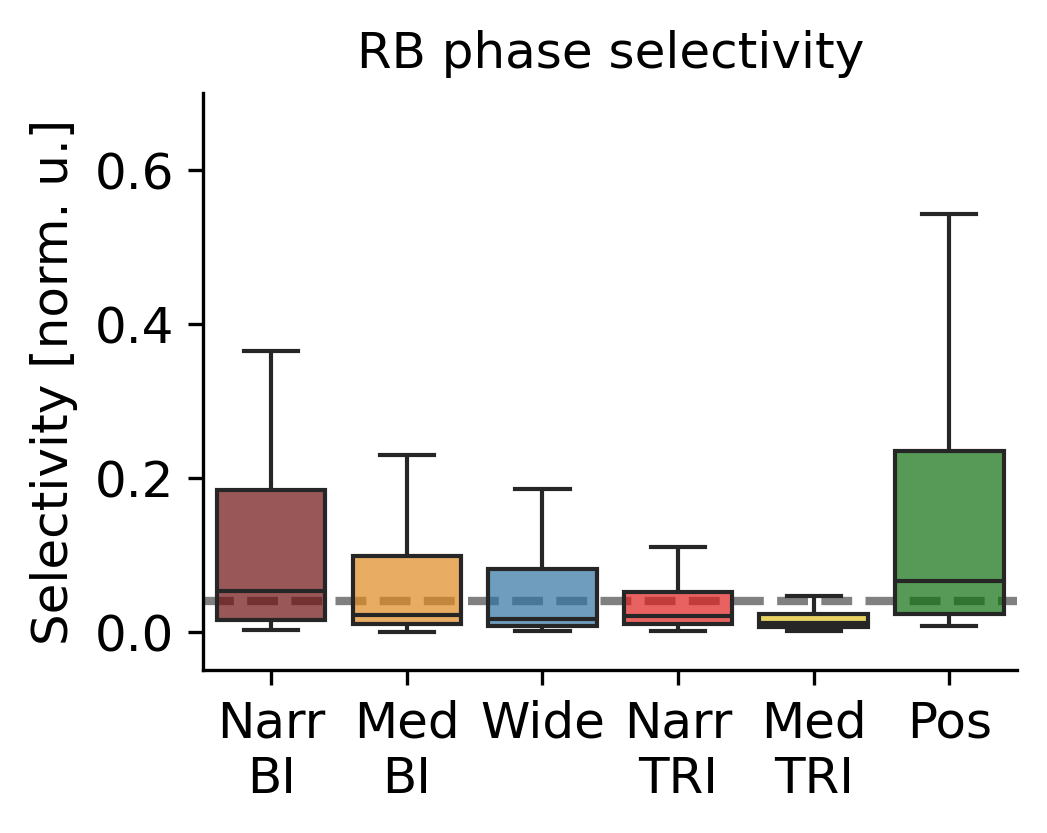

In [23]:
fig, ax = plt.subplots(dpi=300)
fig.set_figwidth(set_params['boxplot_width'])
fig.set_figheight(set_params['boxplot_height'])

ax.set_title('RB phase selectivity')
set_params['y_select'] = 'norm_RB_phase_selectivity_spikes' # name of the selectivity measure used in the boxplot
set_params['y_name'] = 'Norm. sel.'
set_params['y_label'] = 'Selectivity [norm. u.]'
aux_plot_select_boxplot_fig5(df_merged_area,ax,set_params)

plt.show()
plt.close()

### Test of dominance of sel. of POS

In [24]:
classes = df_merged_area['final_class'].unique()

results = []

# Loop over all classes except UP
for cls in classes:
    if cls == 'UP':
        continue
    
    up_vals = df_merged_area.loc[df_merged_area['final_class'] == 'UP',
                                 'norm_RB_phase_selectivity_spikes']
    other_vals = df_merged_area.loc[df_merged_area['final_class'] == cls,
                                    'norm_RB_phase_selectivity_spikes']
    # Mann–Whitney U test
    u_stat, p_val = stats.mannwhitneyu(up_vals, other_vals, alternative='greater')
    
    results.append({
        'comparison': f'UP vs {cls}',
        'u_stat': u_stat,
        'p_value': p_val,
        'n_UP': len(up_vals),
        'n_other': len(other_vals)
    })

results_df = pd.DataFrame(results)

# Multiple-testing correction (FDR)
results_df['p_fdr'] = multipletests(results_df['p_value'], method='fdr_bh')[1]

results_df

,comparison,u_stat,p_value,n_UP,n_other,p_fdr
0,UP vs DOWN_wide,22158.0,8.435165e-08,69,462,1.405861e-07
1,UP vs DOWN_narrow_sharp,7887.0,2.430442e-08,69,157,6.076104e-08
2,UP vs DOWN_narrow_shallow,8426.0,3.890789e-02,69,214,3.890789e-02
3,UP vs DOWN_medium_sharp,10064.0,7.949024e-15,69,179,3.974512e-14
4,UP vs DOWN_medium_shallow,24439.0,1.643651e-06,69,527,2.054564e-06


In [25]:
# Multiple-testing correction (FDR)
results_df['p_fdr'] = multipletests(results_df['p_value'], method='bonferroni')[1]

results_df

,comparison,u_stat,p_value,n_UP,n_other,p_fdr
0,UP vs DOWN_wide,22158.0,8.435165e-08,69,462,4.217582e-07
1,UP vs DOWN_narrow_sharp,7887.0,2.430442e-08,69,157,1.215221e-07
2,UP vs DOWN_narrow_shallow,8426.0,3.890789e-02,69,214,1.945394e-01
3,UP vs DOWN_medium_sharp,10064.0,7.949024e-15,69,179,3.974512e-14
4,UP vs DOWN_medium_shallow,24439.0,1.643651e-06,69,527,8.218254e-06


### Group test for L4 units

In [26]:
# Classes of interest
down_classes = ['DOWN_wide', 'DOWN_narrow_shallow', 'DOWN_medium_shallow']

results = []

# Loop over all pairwise combinations
for cls1, cls2 in combinations(down_classes, 2):
    
    vals1 = df_merged_area.loc[df_merged_area['final_class'] == cls1,
                               'norm_RB_phase_selectivity_spikes']
    vals2 = df_merged_area.loc[df_merged_area['final_class'] == cls2,
                               'norm_RB_phase_selectivity_spikes']
    
    # Mann–Whitney U test
    u_stat, p_val = stats.mannwhitneyu(vals1, vals2, alternative='two-sided')
    
    results.append({
        'comparison': f'{cls1} vs {cls2}',
        'u_stat': u_stat,
        'p_value': p_val,
        'n1': len(vals1),
        'n2': len(vals2),
        'median1': vals1.median(),
        'median2': vals2.median()
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Bonferroni correction
results_df['p_bonf'] = multipletests(results_df['p_value'], method='bonferroni')[1]

results_df

,comparison,u_stat,p_value,n1,n2,median1,median2,p_bonf
0,DOWN_wide vs DOWN_narrow_shallow,36210.0,2.155218e-08,462,214,0.016357,0.052399,6.465654e-08
1,DOWN_wide vs DOWN_medium_shallow,112562.0,4.065286e-02,462,527,0.016357,0.022226,1.219586e-01
2,DOWN_narrow_shallow vs DOWN_medium_shallow,68590.0,3.835015e-06,214,527,0.052399,0.022226,1.150504e-05


### Selectivity ratios

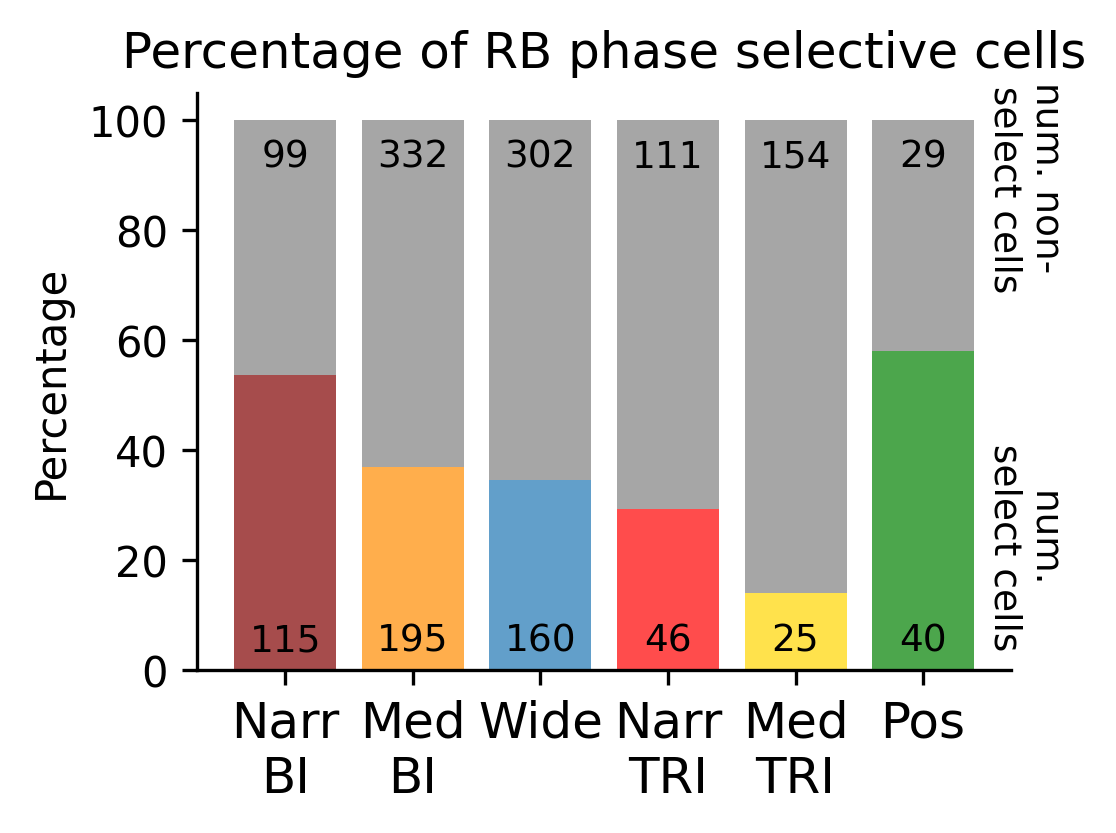

In [27]:
fig, ax = plt.subplots(dpi=300)
fig.set_figwidth(set_params['boxplot_width'])
fig.set_figheight(set_params['boxplot_height'])

ax.set_title('Percentage of RB phase selective cells')
set_params['y_select'] = 'norm_RB_phase_selectivity_spikes'
aux_plot_select_ratios_fig5(df_merged_area,ax,set_params)

plt.show()
plt.close()

### Circular histograms

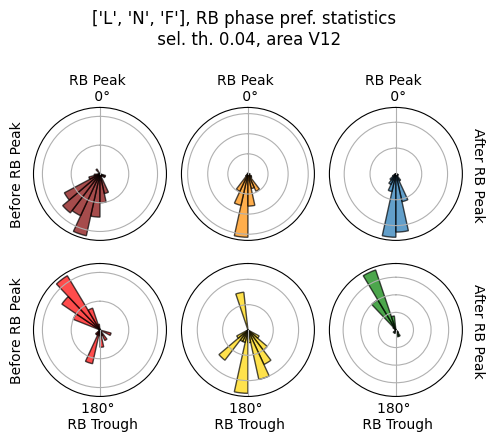

In [28]:
set_params['plot_suptitle'] = f'{MONKEY_LIST}, RB phase pref. statistics \n sel. th. 0.04, area {AREA}'
set_params['pref_phase'] = 'pref_RB_phase_spikes'
set_params['n_bins_hist'] = 30
set_params['font_size'] = 10
plot_CH_panel_fig5(df_merged_area, set_params,save=False,path='')

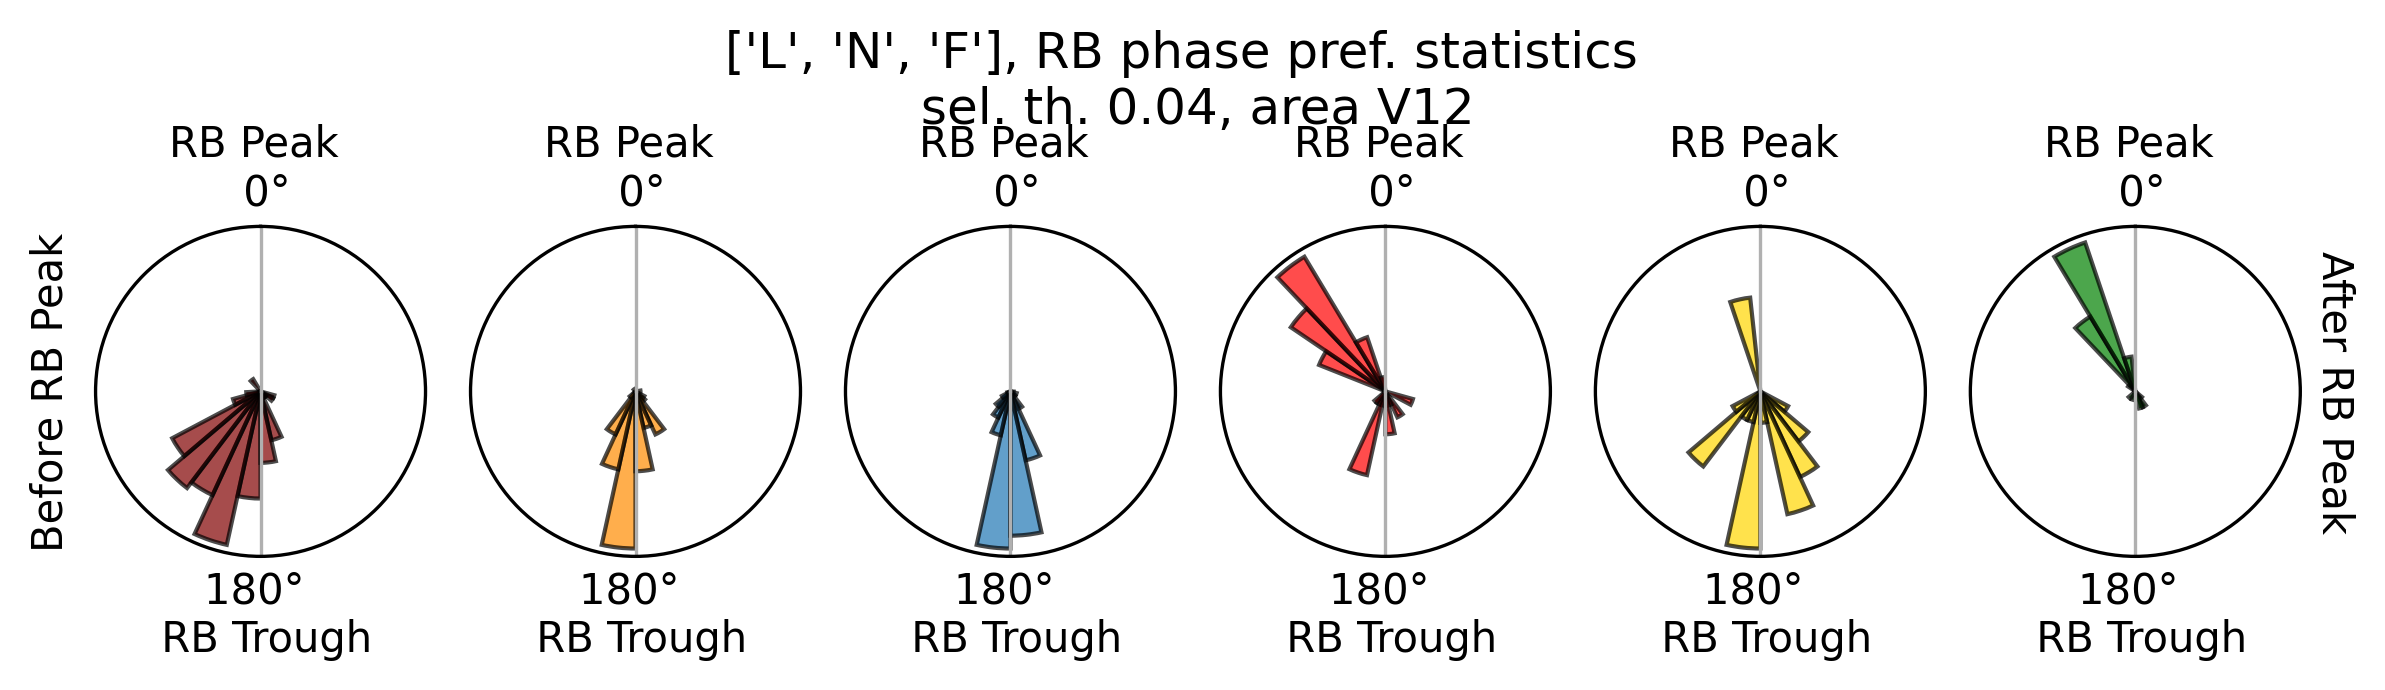

In [29]:
plot_CH_panel_fig5_row(df_merged_area, set_params,save=False,path='')

### Phase aligned

In [30]:
df_first_neg_peak_v1 = df_first_neg_peak[df_first_neg_peak['area']=='V1']

In [31]:
N = 8
MIN_VAL = -N*2*np.pi
MAX_VAL = N*2*np.pi

In [32]:
first_peak_phases_dict = {}
for cl in FINAL_CLASSES:
    first_peak_phases_dict[cl] = np.array(list_merge(df_first_neg_peak_v1[f'phases_spikes_{cl}'].values))

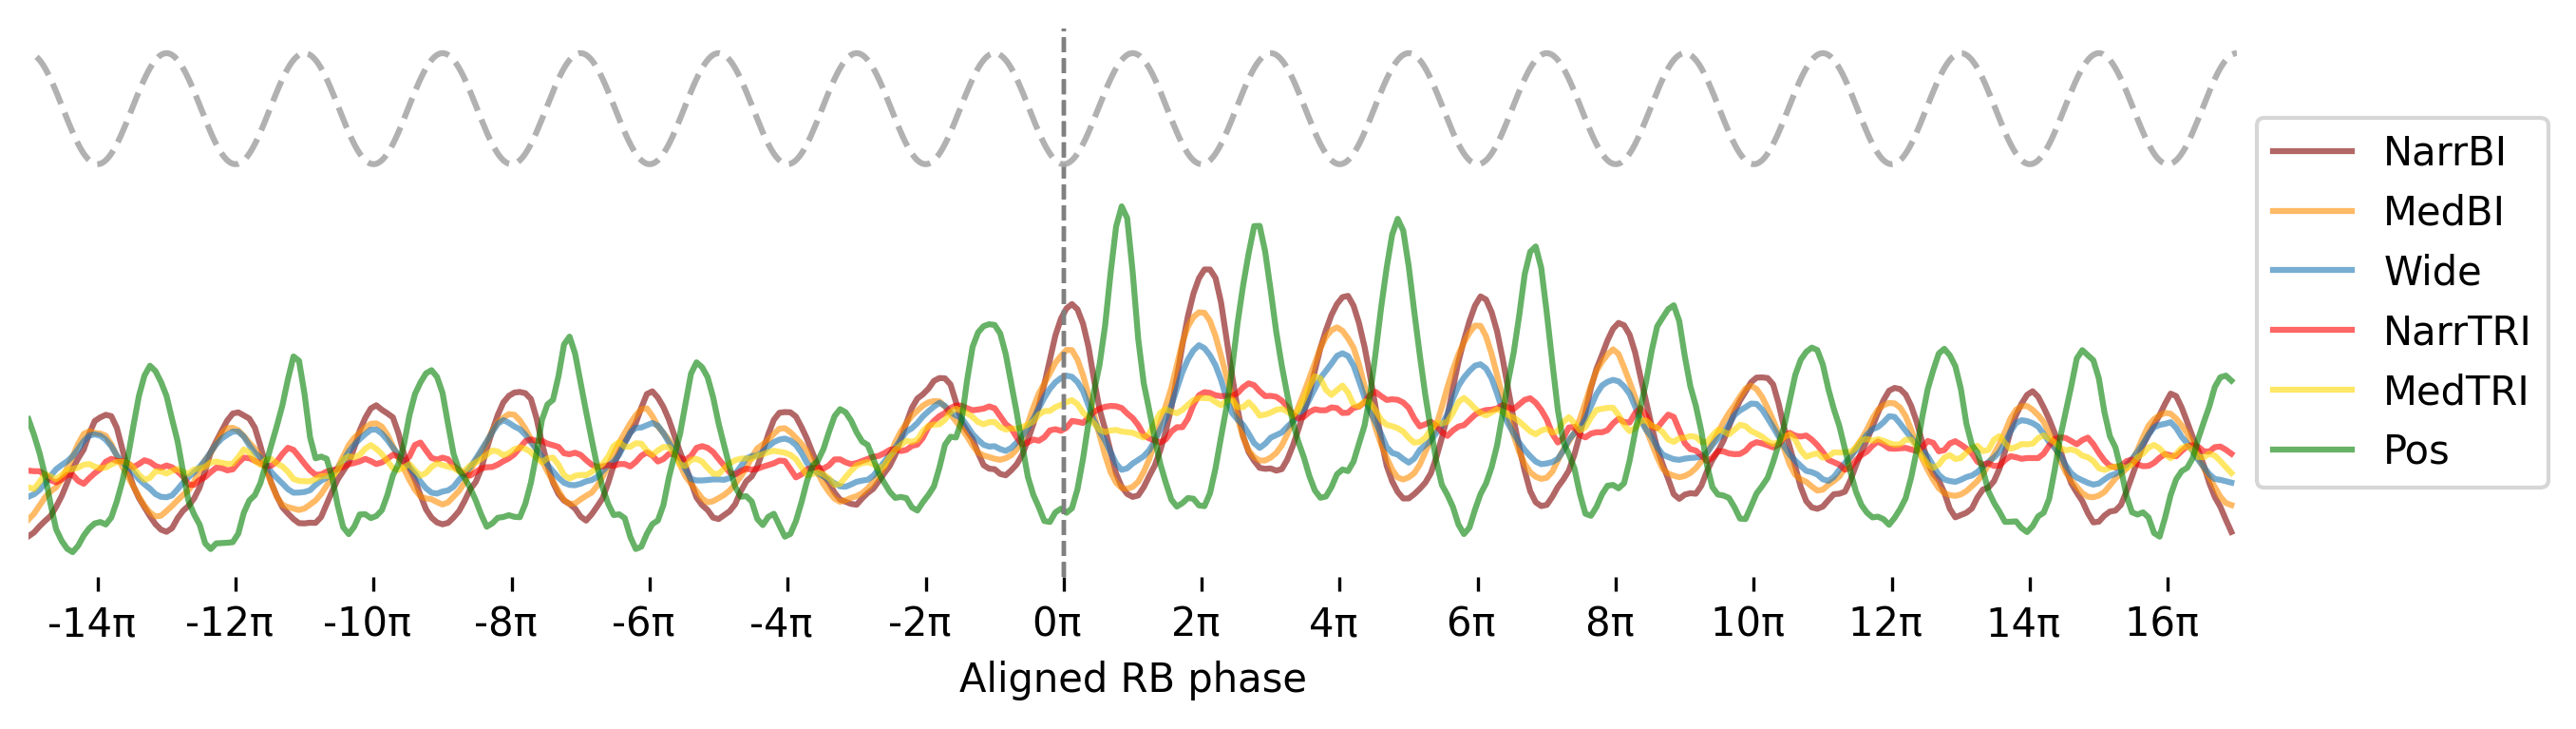

In [33]:
fig, ax = plt.subplots(dpi=300)
fig.set_figheight(2.5)
fig.set_figwidth(10)

#plt.suptitle('All monkeys, first trough aligned phases spikes overlaid \n Gaussian smoothing ')

for idx, cl in enumerate(FINAL_CLASSES):
    data = first_peak_phases_dict[cl]
    data = data[(data>MIN_VAL) & (data<MAX_VAL)]  # only the phases that we picked
    n, bins = np.histogram(data, bins=400, density=True)
    data_smooth = gaussian_filter1d(n,sigma=1)*1.3
    #data_smooth = (data_smooth-np.min(data_smooth))/(np.max(data_smooth)-np.min(data_smooth))
    ax.plot(bins[:-1],data_smooth,color=CLASS_COLORS[cl],alpha=0.6,label=CLASS_DICT[cl])
    #ax.fill_between(bins[:-1],shift,data_smooth+shift,color=CLASS_COLORS[cl],alpha=0.5)
    ax.set_xlim([MIN_VAL,MAX_VAL])
    ax.axvline(-np.pi,ls='dashed',alpha=1,color='gray',linewidth=1)
    for sp in ['top','bottom','right','left']:
        ax.spines[sp].set_visible(False)
    ax.set_xticks(np.arange(-N+1, N+1 ) * 2*np.pi - np.pi)
    ax.set_xticklabels([f'{int(2*n)}π ' for n in np.arange(-N+1,N+1)])
    ax.set_xlabel('Aligned RB phase')
    ax.set_yticks([])

# plotting sine a an ilustration of the RB phase
x = np.linspace(-(N+1)*2* np.pi, (N)*2*np.pi, 1000)
y = np.cos(x)
ax.plot(x,y*0.002+0.025,color='darkgray',ls='dashed',alpha=0.9)

#plt.tight_layout()
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()
plt.close()

### FR ratio strong/weak RB

In [34]:
set_params['box_xlabel_fontsize'] = 12  # size of the font at the x axis
set_params['box_xlabel_rotation'] = 0
set_params['box_ylabel_fontsize'] = 12
set_params['box_alpha'] = 0.7
set_params['box_line_width'] = 1
set_params['box_hline_width'] = 2
set_params['boxplot_width'] = 3.5
set_params['boxplot_height'] = 2.5

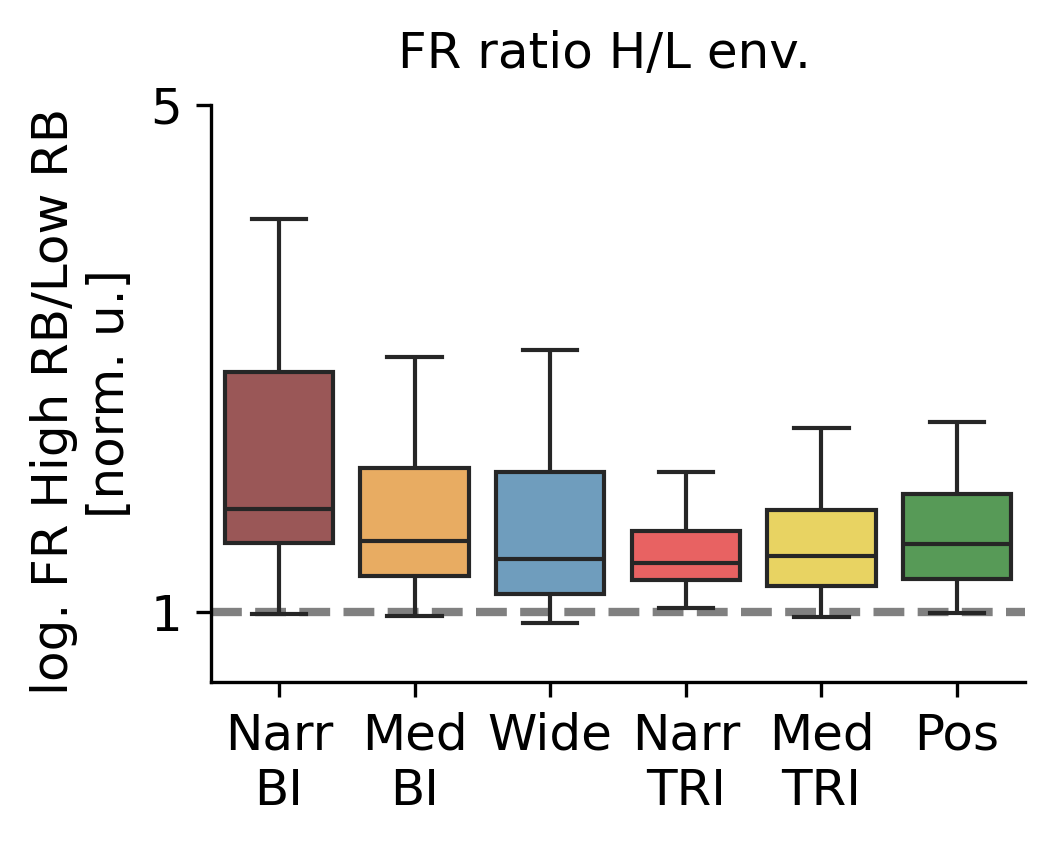

In [35]:
fig, ax = plt.subplots(dpi=300)
fig.set_figwidth(set_params['boxplot_width'])
fig.set_figheight(set_params['boxplot_height'])

set_params['FR_ratio_name'] = 'FR_high_env_low_env_median_ratio'
#fig.suptitle('FR ratio High VS Low RB envelope (median split) ALL EYES')
fig.suptitle('FR ratio H/L env.')
aux_plot_FR_ratio_boxplot(df_merged_area,ax,set_params)

plt.show()
plt.close()

### Testing dominance of FR of POS

In [36]:
fr = df_merged_area['FR_high_env_low_env_median_ratio']
classes = df_merged_area['final_class'].unique()

results = []

# Loop over all classes except UP
for cls in classes:
    if cls == 'UP':
        continue
    
    up_vals = df_merged_area.loc[df_merged_area['final_class'] == 'UP',
                                 'FR_high_env_low_env_median_ratio']
    other_vals = df_merged_area.loc[df_merged_area['final_class'] == cls,
                                    'FR_high_env_low_env_median_ratio']
    # Mann–Whitney U test
    u_stat, p_val = stats.mannwhitneyu(up_vals, other_vals, alternative='greater')
    
    results.append({
        'comparison': f'UP vs {cls}',
        'u_stat': u_stat,
        'p_value': p_val,
        'n_UP': len(up_vals),
        'n_other': len(other_vals)
    })

results_df = pd.DataFrame(results)

# Multiple-testing correction (FDR)
results_df['p_fdr'] = multipletests(results_df['p_value'], method='fdr_bh')[1]

results_df


,comparison,u_stat,p_value,n_UP,n_other,p_fdr
0,UP vs DOWN_wide,17801.0,0.058691,69,462,0.123957
1,UP vs DOWN_narrow_sharp,6227.0,0.036782,69,157,0.123957
2,UP vs DOWN_narrow_shallow,5040.0,0.999963,69,214,0.999963
3,UP vs DOWN_medium_sharp,6907.0,0.074374,69,179,0.123957
4,UP vs DOWN_medium_shallow,17092.0,0.791145,69,527,0.988932


In [37]:
results_df['p_bonf'] = multipletests(results_df['p_value'], method='bonferroni')[1]

results_df

,comparison,u_stat,p_value,n_UP,n_other,p_fdr,p_bonf
0,UP vs DOWN_wide,17801.0,0.058691,69,462,0.123957,0.293455
1,UP vs DOWN_narrow_sharp,6227.0,0.036782,69,157,0.123957,0.183908
2,UP vs DOWN_narrow_shallow,5040.0,0.999963,69,214,0.999963,1.000000
3,UP vs DOWN_medium_sharp,6907.0,0.074374,69,179,0.123957,0.371871
4,UP vs DOWN_medium_shallow,17092.0,0.791145,69,527,0.988932,1.000000


In [38]:
# Green FR only signif. higher from Triphasic units, not for L4

### Group comparison for L4 + POS units

In [39]:
# Classes of interest
down_classes = ['DOWN_wide', 'DOWN_narrow_shallow', 'DOWN_medium_shallow','UP']

results = []

# Loop over all pairwise combinations
for cls1, cls2 in combinations(down_classes, 2):
    
    vals1 = df_merged_area.loc[df_merged_area['final_class'] == cls1,
                               'FR_high_env_low_env_median_ratio']
    vals2 = df_merged_area.loc[df_merged_area['final_class'] == cls2,
                               'FR_high_env_low_env_median_ratio']
    
    # Mann–Whitney U test
    u_stat, p_val = stats.mannwhitneyu(vals1, vals2, alternative='two-sided')
    
    results.append({
        'comparison': f'{cls1} vs {cls2}',
        'u_stat': u_stat,
        'p_value': p_val,
        'n1': len(vals1),
        'n2': len(vals2),
        'median1': vals1.median(),
        'median2': vals2.median()
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Bonferroni correction
results_df['p_bonf'] = multipletests(results_df['p_value'], method='bonferroni')[1]

results_df

,comparison,u_stat,p_value,n1,n2,median1,median2,p_bonf
0,DOWN_wide vs DOWN_narrow_shallow,31273.0,1.477497e-14,462,214,1.181946,1.387195,8.864981e-14
1,DOWN_wide vs DOWN_medium_shallow,102954.0,2.779349e-05,462,527,1.181946,1.253396,1.667609e-04
2,DOWN_wide vs UP,14077.0,1.173819e-01,462,69,1.181946,1.238945,7.042915e-01
3,DOWN_narrow_shallow vs DOWN_medium_shallow,70108.0,2.047521e-07,214,527,1.387195,1.253396,1.228512e-06
4,DOWN_narrow_shallow vs UP,9726.0,7.413968e-05,214,69,1.387195,1.238945,4.448381e-04
5,DOWN_medium_shallow vs UP,19271.0,4.181369e-01,527,69,1.253396,1.238945,1.000000e+00


### Group comparison for all units, just one test

In [40]:
down_classes = ['DOWN_wide', 'DOWN_narrow_shallow', 'DOWN_medium_shallow','UP']
groups = [
    df_merged_area.loc[df_merged_area['final_class'] == cls,
                       'FR_high_env_low_env_median_ratio']
    for cls in down_classes
]

stat, p = kruskal(*groups)
print(stat, p)


65.51226834948056 3.8974158851627045e-14


### Group comparison for all units except Maroon, just one test

In [41]:
down_classes = ['DOWN_wide', 'DOWN_narrow_sharp', 'DOWN_medium_shallow','DOWN_medium_sharp','UP']
groups = [
    df_merged_area.loc[df_merged_area['final_class'] == cls,
                       'FR_high_env_low_env_median_ratio']
    for cls in down_classes
]

stat, p = kruskal(*groups)
print(stat, p)

27.574001571906592 1.5214641815805736e-05


### Group comparison for all units except Maroon, just one test

In [42]:
# modulation
target_cls = 'DOWN_narrow_shallow'
other_classes = [c for c in df_merged_area['final_class'].unique() if c != target_cls]

results = []
target_vals = df_merged_area.loc[df_merged_area['final_class'] == target_cls,
                                 'FR_high_env_low_env_median_ratio']

for cls in other_classes:
    other_vals = df_merged_area.loc[df_merged_area['final_class'] == cls,
                                    'FR_high_env_low_env_median_ratio']
    u_stat, p_val = stats.mannwhitneyu(target_vals, other_vals, alternative='greater')

    results.append({
        'comparison': f'{target_cls} > {cls}',
        'u_stat': u_stat,
        'p_value': p_val,
        'n_target': len(target_vals),
        'n_other': len(other_vals)
    })

results_df = pd.DataFrame(results)
results_df['p_fdr'] = multipletests(results_df['p_value'], method='bonferroni')[1]
results_df

,comparison,u_stat,p_value,n_target,n_other,p_fdr
0,DOWN_narrow_shallow > DOWN_wide,67595.0,7.387484e-15,214,462,3.693742e-14
1,DOWN_narrow_shallow > DOWN_narrow_sharp,25103.0,2.038754e-16,214,157,1.019377e-15
2,DOWN_narrow_shallow > DOWN_medium_sharp,27543.0,3.694959e-14,214,179,1.847480e-13
3,DOWN_narrow_shallow > DOWN_medium_shallow,70108.0,1.023760e-07,214,527,5.118802e-07
4,DOWN_narrow_shallow > UP,9726.0,3.706984e-05,214,69,1.853492e-04


### Biphasic VS Triphasic testing 

In [43]:
# Classes of interest
down_classes = ['DOWN_narrow_shallow', 'DOWN_narrow_sharp']

results = []

# Loop over all pairwise combinations
for cls1, cls2 in combinations(down_classes, 2):
    
    vals1 = df_merged_area.loc[df_merged_area['final_class'] == cls1,
                               'FR_high_env_low_env_median_ratio']
    vals2 = df_merged_area.loc[df_merged_area['final_class'] == cls2,
                               'FR_high_env_low_env_median_ratio']
    
    # Mann–Whitney U test
    u_stat, p_val = stats.mannwhitneyu(vals1, vals2, alternative='greater')
    
    results.append({
        'comparison': f'{cls1} vs {cls2}',
        'u_stat': u_stat,
        'p_value': p_val,
        'n1': len(vals1),
        'n2': len(vals2),
        'median1': vals1.median(),
        'median2': vals2.median()
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

results_df

,comparison,u_stat,p_value,n1,n2,median1,median2
0,DOWN_narrow_shallow vs DOWN_narrow_sharp,25103.0,2.038754e-16,214,157,1.387195,1.16964


In [44]:
# Classes of interest
down_classes = ['DOWN_narrow_shallow', 'DOWN_narrow_sharp']

results = []

# Loop over all pairwise combinations
for cls1, cls2 in combinations(down_classes, 2):
    
    vals1 = df_merged_area.loc[df_merged_area['final_class'] == cls1,
                               'norm_RB_phase_selectivity_spikes']
    vals2 = df_merged_area.loc[df_merged_area['final_class'] == cls2,
                               'norm_RB_phase_selectivity_spikes']
    
    # Mann–Whitney U test
    u_stat, p_val = stats.mannwhitneyu(vals1, vals2, alternative='greater')
    
    results.append({
        'comparison': f'{cls1} vs {cls2}',
        'u_stat': u_stat,
        'p_value': p_val,
        'n1': len(vals1),
        'n2': len(vals2),
        'median1': vals1.median(),
        'median2': vals2.median()
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

results_df

,comparison,u_stat,p_value,n1,n2,median1,median2
0,DOWN_narrow_shallow vs DOWN_narrow_sharp,22481.0,1.295409e-08,214,157,0.052399,0.019919


In [45]:
# Classes of interest
down_classes = ['DOWN_medium_shallow', 'DOWN_medium_sharp']

results = []

# Loop over all pairwise combinations
for cls1, cls2 in combinations(down_classes, 2):
    
    vals1 = df_merged_area.loc[df_merged_area['final_class'] == cls1,
                               'FR_high_env_low_env_median_ratio']
    vals2 = df_merged_area.loc[df_merged_area['final_class'] == cls2,
                               'FR_high_env_low_env_median_ratio']
    
    # Mann–Whitney U test
    u_stat, p_val = stats.mannwhitneyu(vals1, vals2, alternative='greater')
    
    results.append({
        'comparison': f'{cls1} vs {cls2}',
        'u_stat': u_stat,
        'p_value': p_val,
        'n1': len(vals1),
        'n2': len(vals2),
        'median1': vals1.median(),
        'median2': vals2.median()
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

results_df

,comparison,u_stat,p_value,n1,n2,median1,median2
0,DOWN_medium_shallow vs DOWN_medium_sharp,55152.0,0.000353,527,179,1.253396,1.192294


In [46]:
# Classes of interest
down_classes = ['DOWN_medium_shallow', 'DOWN_medium_sharp']

results = []

# Loop over all pairwise combinations
for cls1, cls2 in combinations(down_classes, 2):
    
    vals1 = df_merged_area.loc[df_merged_area['final_class'] == cls1,
                               'norm_RB_phase_selectivity_spikes']
    vals2 = df_merged_area.loc[df_merged_area['final_class'] == cls2,
                               'norm_RB_phase_selectivity_spikes']
    
    # Mann–Whitney U test
    u_stat, p_val = stats.mannwhitneyu(vals1, vals2, alternative='greater')
    
    results.append({
        'comparison': f'{cls1} vs {cls2}',
        'u_stat': u_stat,
        'p_value': p_val,
        'n1': len(vals1),
        'n2': len(vals2),
        'median1': vals1.median(),
        'median2': vals2.median()
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

results_df

,comparison,u_stat,p_value,n1,n2,median1,median2
0,DOWN_medium_shallow vs DOWN_medium_sharp,60888.0,2.939582e-09,527,179,0.022226,0.011871
